In [14]:
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as nc
import h5py
import scipy

In [2]:
Rignot = nc.Dataset('Data/melt_rates/rignot-2013/Ant_MeltingRate.v2.nc')
Rignot = np.asarray(Rignot['melt_actual'])

In [3]:
Adusumilli = h5py.File('Data/melt_rates/adusumilli-2020/bb0448974g_3_1.h5')
Adusumilli = np.asarray(Adusumilli['w_b'])

In [4]:
print(Rignot.shape, Adusumilli.shape)

(5601, 5601) (10229, 10941)


In [51]:
SOhi_R = -np.load('Data/melt_rates/SOhi-v2/Resamp_RignotGrid.npy')
SOhi_A = -np.load('Data/melt_rates/SOhi-v2/Resamp_AdusumilliGrid.npy')

print(SOhi_R.shape, SOhi_A.shape)

(5601, 5601) (10229, 10941)


In [6]:
AID = np.load('Data/masks/Adusumilli_ID_mask.npy')

RID = np.load('Data/masks/Rignot_ID_mask.npy')

print(RID.shape, AID.shape)

(5601, 5601) (10229, 10941)


In [7]:
AID[np.logical_or(np.isnan(Adusumilli), np.isnan(SOhi_A))] = np.nan
RID[np.logical_or(np.isnan(Rignot), np.isnan(SOhi_R))] = np.nan

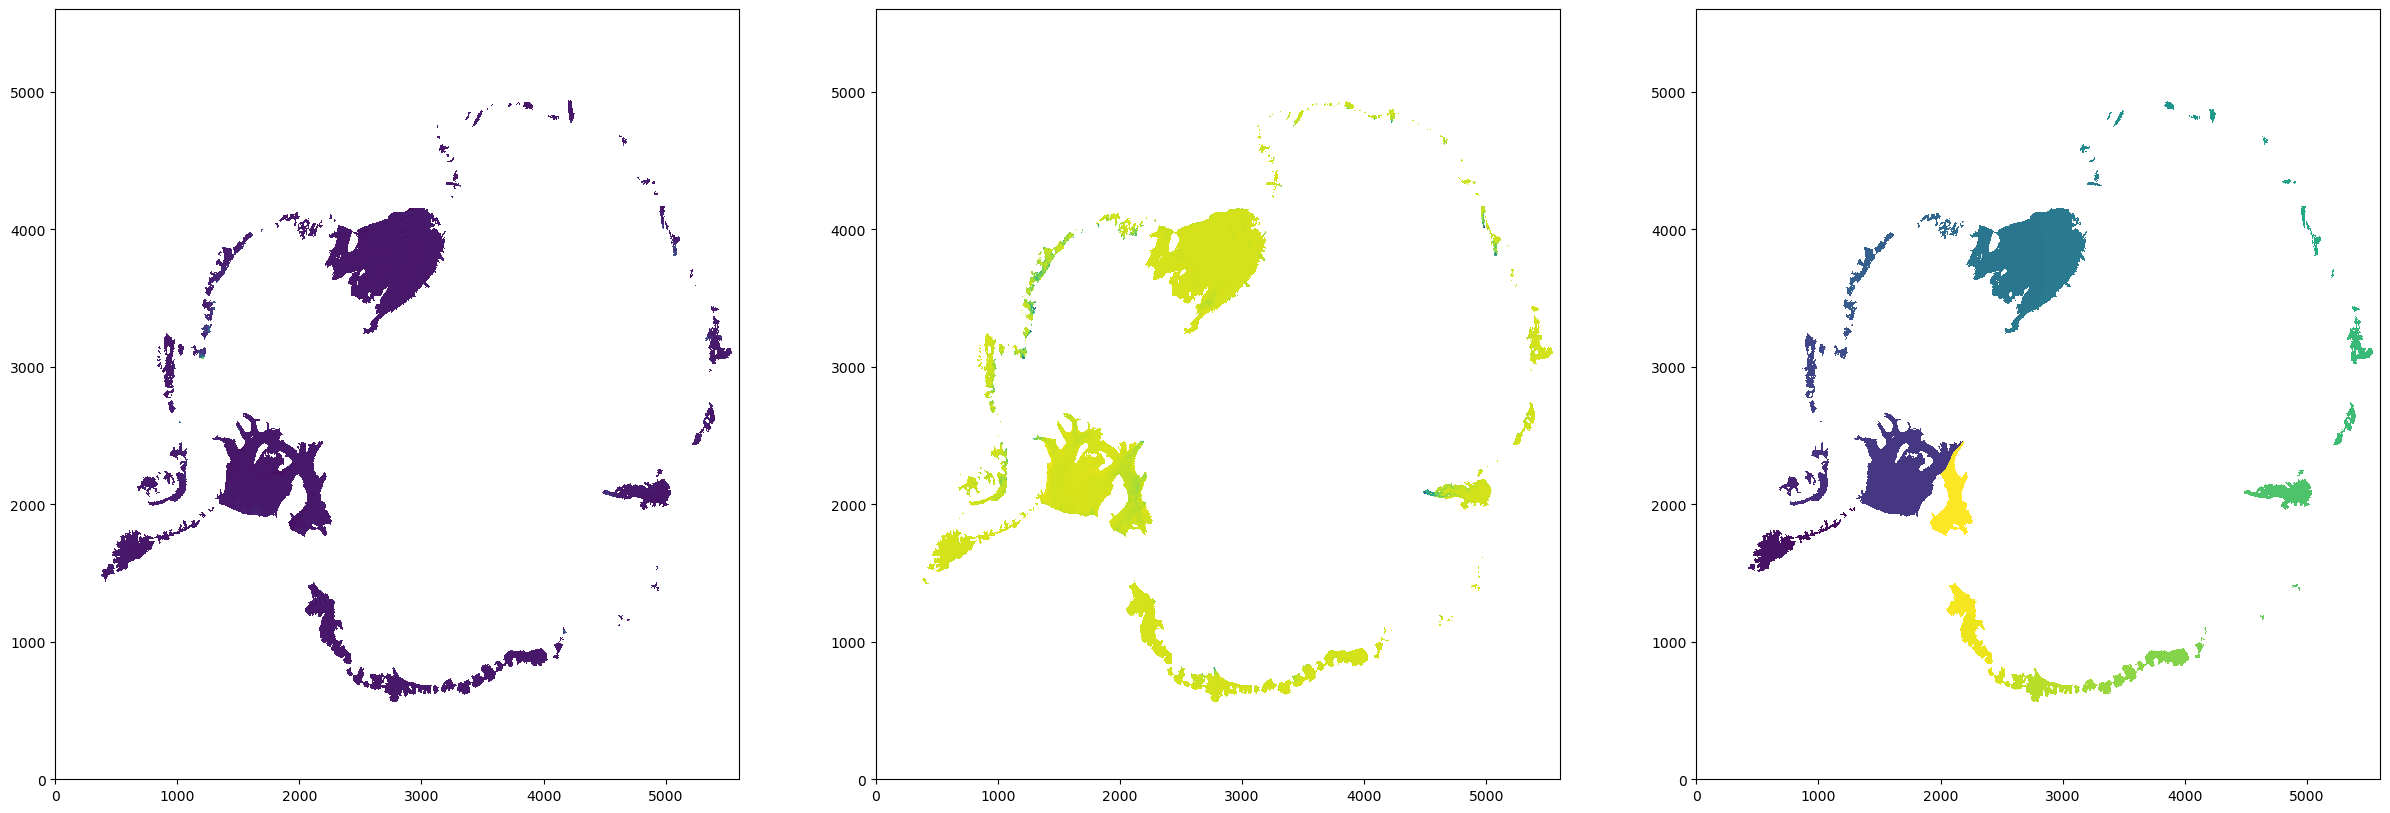

In [8]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3)

ax[0].pcolormesh(Rignot)
ax[1].pcolormesh(SOhi_R)
ax[2].pcolormesh(RID)

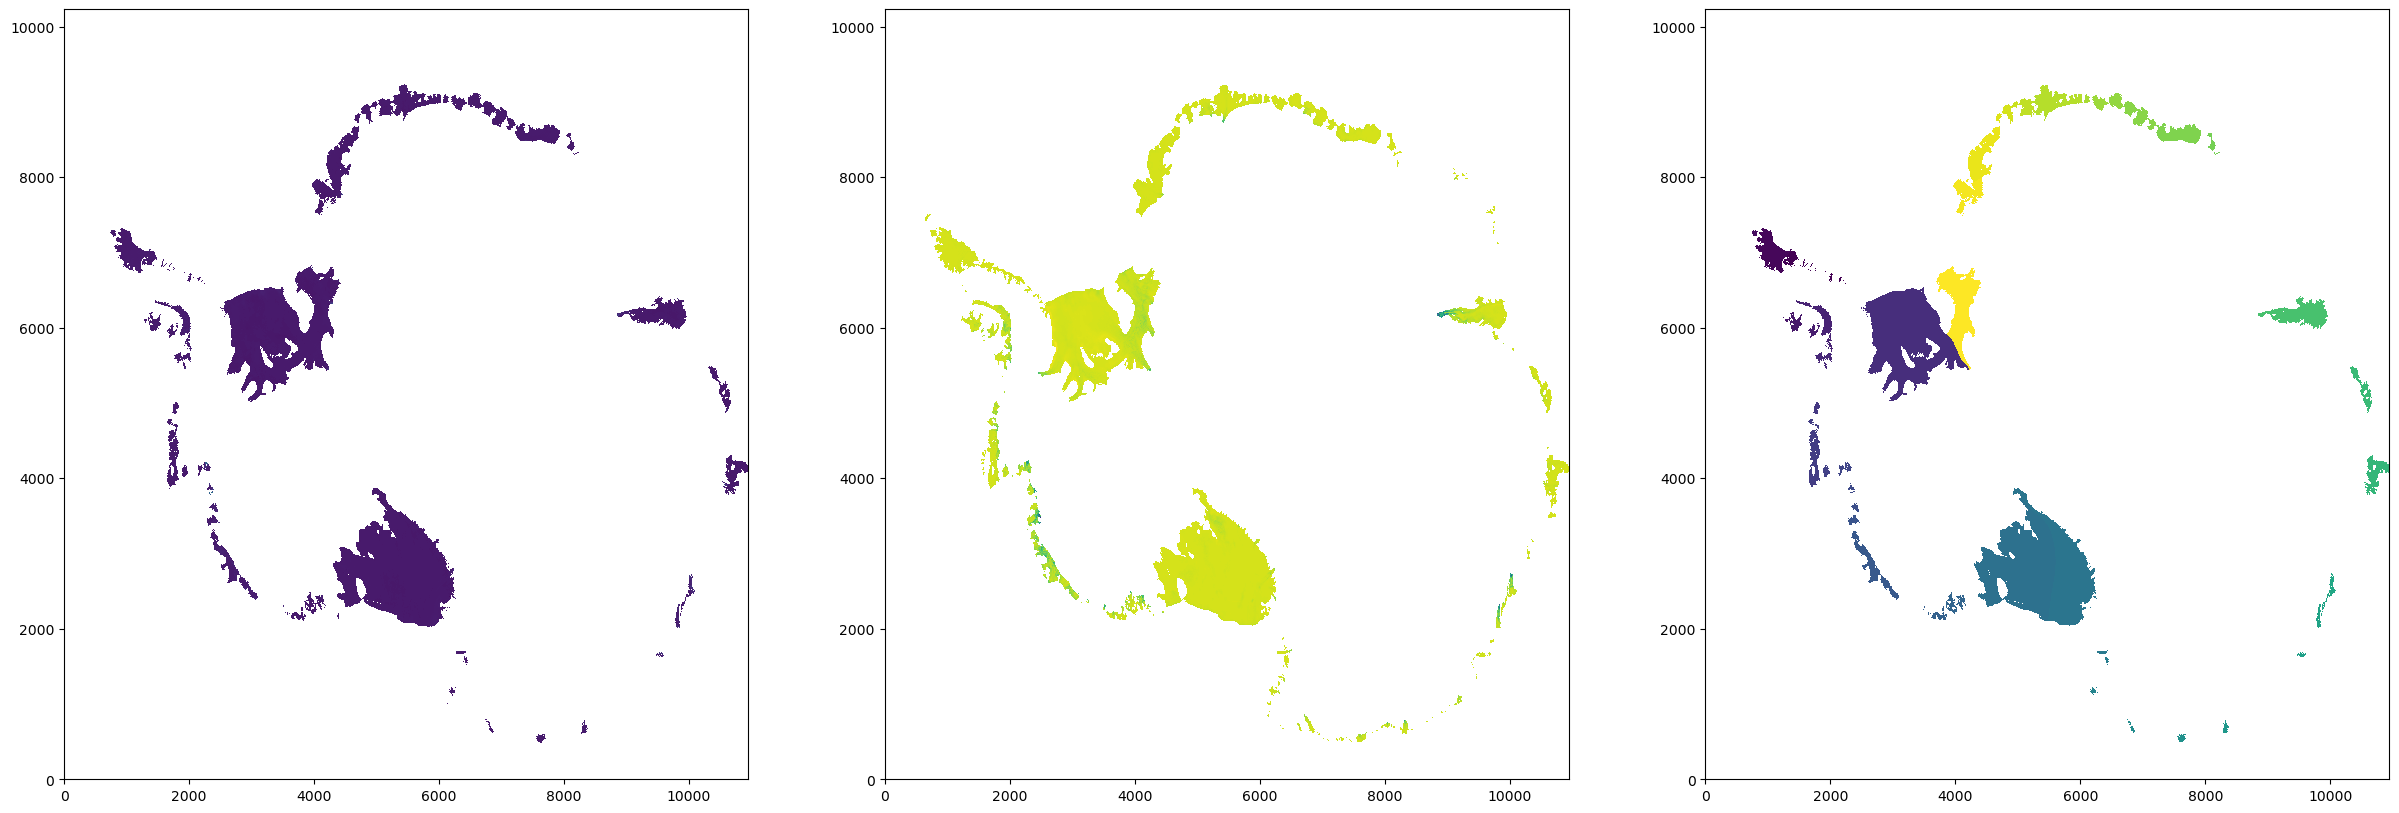

In [9]:
fig, ax = plt.subplots(figsize=(30,10), ncols=3)

ax[0].pcolormesh(Adusumilli)
ax[1].pcolormesh(SOhi_A)
ax[2].pcolormesh(AID)

## Mean, Std, Corr

In [54]:
def linearize(IS_num, ref_data, samp_data, input_mask):

    ## Rignot 
    mask = np.ones(input_mask.shape)
    mask[input_mask != IS_num] = np.nan

    satellite = ref_data * mask 
    model = samp_data * mask 

    satellite = satellite.flatten()
    model = model.flatten()

    satellite = satellite[~np.isnan(satellite)]
    model = model[~np.isnan(model)] 

    assert len(satellite) == len(model)

    return np.mean(model), np.std(model), np.mean(satellite), np.std(satellite), np.corrcoef(model, satellite)[1,0], len(satellite)


In [55]:
IS_names = ["Larsen G", "Larsen F","Larsen E","Larsen D", "Larsen C","Larsen B","Wordie","Wilkins",
       "Bach","George VI","Stange",  "Ronne","Ferrigno","Venable",
       "Abbot","Cosgrove","Pine Island","Thwaites","Crosson","Dotson",
       "Getz","Land","Nickerson","Sulzberger","Swinburne","Withrow","Ross West","Ross East", "Drygalski","Nansen",
       "Aviator","Mariner","Lillie","Rennick","Cook","Ninnis","Mertz","Dibble","Holmes","Moscow University","Totten",
       "Vincennes","Conger_Glenzer","Tracy_Tremenchus","Shackleton","West","Publications","Amery",
       "Wilma_Robert_Downer","Edward VIII","Rayner_Thyer","Shirase","Prince Harald","Baudouin",
       "Borchgrevink","Lazarev","Nivl","Vigrid","Fimbul","Jelbart","Atka","Ekstrom","Quar","Riiser-Larsen",
       "Brunt_Stancomb","Filchner"]

In [56]:
SH_mean = []
SH_std = []

R_mean = []
R_std = []

A_mean = []
A_std = []

S_R_corr = []
S_A_corr = []

indices = [3, 4, 5, 9, 8, 7, 10, ## peninsula
           13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, ## west ant
           28, 29, 31, 39, 33, 34, 36, 38, 40, 44, 45,47, ## East Ant
           52, 64, 63, 62, 61, 53, 54, 55, 58, 56, 57, 60, 59,
           26, 27, ## Ross
           11, 65] ## filchner-ronne

for index in indices: 
    print()
    
    a, b, c, d, e, f = linearize(index, ref_data = Rignot, samp_data = SOhi_R, input_mask = RID)

    print(f"{IS_names[index]} ({f:.0f})")
    print(f"SOhi: {a:.2f} ± {b:.2f}")
    print(f"Rignot: {c:.2f} ± {d:.2f}, corr = {e:.2f}")
    
    SH_mean.append(a)
    SH_std.append(b)

    R_mean.append(c)
    R_std.append(d)

    S_R_corr.append(e)

    a, b, c, d, e, f = linearize(index, ref_data = Adusumilli, samp_data = SOhi_A, input_mask = AID)

    print(f"Adusumilli: {c:.2f} ± {d:.2f}, corr = {e:.2f}")
    
    A_mean.append(c)
    A_std.append(d)

    S_A_corr.append(e)



    


Larsen D (21435)
SOhi: 0.71 ± 1.25
Rignot: -0.06 ± 1.07, corr = 0.16
Adusumilli: 2.25 ± 3.28, corr = 0.09

Larsen C (46759)
SOhi: 0.73 ± 0.99
Rignot: 0.15 ± 0.95, corr = 0.19
Adusumilli: 1.38 ± 1.78, corr = 0.21

Larsen B (1948)
SOhi: 0.73 ± 0.67
Rignot: 1.17 ± 1.87, corr = 0.11
Adusumilli: 1.71 ± 3.54, corr = 0.45

George VI (22476)
SOhi: 9.24 ± 8.88
Rignot: 3.30 ± 2.78, corr = 0.50
Adusumilli: 3.95 ± 2.23, corr = 0.47

Bach (4228)
SOhi: 7.08 ± 4.89
Rignot: 1.73 ± 0.97, corr = -0.09
Adusumilli: 2.79 ± 1.46, corr = 0.02

Wilkins (10302)
SOhi: 4.18 ± 4.05
Rignot: 1.45 ± 1.42, corr = 0.03
Adusumilli: 2.27 ± 0.95, corr = 0.16

Stange (7575)
SOhi: 9.72 ± 11.59
Rignot: 3.43 ± 4.44, corr = 0.70
Adusumilli: 3.63 ± 3.23, corr = 0.62

Venable (3026)
SOhi: 12.92 ± 8.71
Rignot: 4.71 ± 2.76, corr = 0.24
Adusumilli: 3.25 ± 2.14, corr = 0.27

Abbot (28098)
SOhi: 5.99 ± 8.03
Rignot: 1.52 ± 1.98, corr = 0.78
Adusumilli: 1.45 ± 1.19, corr = 0.57

Cosgrove (2833)
SOhi: 9.23 ± 8.12
Rignot: 2.53 ± 2.00, 

In [53]:
for i in range(len(SH_mean)):
    print(SH_mean[i],  SH_std[i], R_mean[i], R_std[i],S_R_corr[i], A_mean[i], A_std[i], S_A_corr[i])

0.7080286559952672 1.2545193691291232 -0.05865760272574382 1.0720684083060312 0.1581188554113818 2.254936218157678 3.275878797008624 0.08811439755292852
0.7274323317217924 0.9915588431344229 0.1518552434816919 0.954911980995344 0.19337067702568264 1.3800209089566557 1.7820285046045128 0.208038473978491
0.7332028161464639 0.6666226972046642 1.167647156076181 1.8746815973551798 0.10984428073334145 1.7127629335852446 3.5438267987464767 0.45069900168551524
9.23941747198016 8.8818288794022 3.295654929638113 2.775653843008987 0.49825769086857685 3.954148753234803 2.2287442974284004 0.47356276168187755
7.082093102079514 4.8884478102959505 1.7254557275850337 0.9728490640999558 -0.09379789002519444 2.787590239639219 1.462477618968471 0.01630767539090807
4.178725097166408 4.047860651431987 1.4532814910712646 1.4174809979116227 0.027449563112468926 2.2736076558674947 0.9521052559998946 0.15729798241655632
9.717392559356744 11.585936605330158 3.4279819837902297 4.4423781956783985 0.697434489303632

## 90th percentile mean, std, %overlap 

In [161]:
def coverage(IS_num, ref_data, samp_data, input_mask):

    ## Rignot 
    mask = np.ones(input_mask.shape)
    mask[input_mask != IS_num] = np.nan

    satellite = ref_data * mask 
    model = samp_data * mask 

    satellite = satellite.flatten()
    model = model.flatten()

    satellite = satellite[mask.flatten() ==1]
    model = model[mask.flatten() ==1 ] 


    assert len(satellite) == len(model)
    #print(f"total grids: {len(satellite)}")

    satellite[satellite < np.nanpercentile(satellite, 90)] = np.nan
    model[model < np.nanpercentile(model, 90)] = np.nan

    s_mean = np.nanmean(satellite)
    m_mean = np.nanmean(model)

    s_stdev = np.nanstd(satellite)
    m_stdev = np.nanstd(model)

    stack = np.vstack((model, satellite))
    flag = np.all(~np.isnan(stack), axis=0)


    perc = np.count_nonzero(flag)/np.count_nonzero(~np.isnan(satellite)) * 100

    return m_mean, m_stdev, s_mean, s_stdev, perc

    

    
    



In [163]:
SH_mean = []
SH_std = []

R_mean = []
R_std = []

A_mean = []
A_std = []

S_R_perc = []
S_A_perc = []

indices = [3, 4, 5, 9, 8, 7, 10, ## peninsula
           13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, ## west ant
           28, 29, 31, 39, 33, 34, 36, 38, 40, 44, 45,47, ## East Ant
           52, 64, 63, 62, 61, 53, 54, 55, 58, 56, 57, 60, 59,
           26, 27, ## Ross
           11, 65] ## filchner-ronne

for index in indices: 
    print()
    
    a, b, c, d, e= coverage(index, ref_data = Rignot, samp_data = SOhi_R, input_mask = RID)

    print(f"{IS_names[index]}")
    print(f"SOhi: {a:.2f} ± {b:.2f}")
    print(f"Rignot: {c:.2f} ± {d:.2f}, overlap = {e:.2f}")
    
    SH_mean.append(a)
    SH_std.append(b)

    R_mean.append(c)
    R_std.append(d)

    S_R_perc.append(e)

    a, b, c, d, e= coverage(index, ref_data = Adusumilli, samp_data = SOhi_A, input_mask = AID)

    print(f"Adusumilli: {c:.2f} ± {d:.2f}, overlap = {e:.2f}")
    
    A_mean.append(c)
    A_std.append(d)

    S_A_perc.append(e)


Larsen D
SOhi: 3.53 ± 1.41
Rignot: 1.81 ± 0.70, overlap = 14.88
Adusumilli: 4.79 ± 9.54, overlap = 23.06

Larsen C
SOhi: 3.08 ± 1.20
Rignot: 1.80 ± 1.03, overlap = 26.30
Adusumilli: 4.17 ± 4.30, overlap = 24.97

Larsen B
SOhi: 2.10 ± 1.01
Rignot: 4.78 ± 1.12, overlap = 35.38
Adusumilli: 9.05 ± 7.61, overlap = 46.91

George VI
SOhi: 29.66 ± 7.30
Rignot: 9.99 ± 3.16, overlap = 36.52
Adusumilli: 8.87 ± 3.06, overlap = 34.16

Bach
SOhi: 17.03 ± 2.87
Rignot: 4.01 ± 1.12, overlap = 21.51
Adusumilli: 5.32 ± 2.28, overlap = 23.71

Wilkins
SOhi: 13.09 ± 5.21
Rignot: 4.75 ± 2.05, overlap = 17.17
Adusumilli: 4.43 ± 1.46, overlap = 21.76

Stange
SOhi: 38.63 ± 10.53
Rignot: 14.48 ± 6.88, overlap = 60.55
Adusumilli: 11.03 ± 5.75, overlap = 57.14

Venable
SOhi: 29.91 ± 3.99
Rignot: 11.44 ± 3.20, overlap = 31.02
Adusumilli: 7.97 ± 3.18, overlap = 39.34

Abbot
SOhi: 26.04 ± 9.73
Rignot: 6.00 ± 3.56, overlap = 69.64
Adusumilli: 3.96 ± 1.69, overlap = 52.82

Cosgrove
SOhi: 27.57 ± 6.02
Rignot: 7.02 ± 3.

/var/folders/2n/5cjcyrz92xq2s13y29jhm27w0000gn/T/ipykernel_6239/2140562629.py:23: RuntimeWarning: Mean of empty slice
  s_mean = np.nanmean(satellite)
/var/folders/2n/5cjcyrz92xq2s13y29jhm27w0000gn/T/ipykernel_6239/2140562629.py:24: RuntimeWarning: Mean of empty slice
  m_mean = np.nanmean(model)
/var/folders/2n/5cjcyrz92xq2s13y29jhm27w0000gn/T/ipykernel_6239/2140562629.py:33: RuntimeWarning: invalid value encountered in scalar divide
  perc = np.count_nonzero(flag)/np.count_nonzero(~np.isnan(satellite)) * 100


Withrow
SOhi: nan ± nan
Rignot: nan ± nan, overlap = nan
Adusumilli: nan ± nan, overlap = nan

Drygalski
SOhi: 30.68 ± 9.67
Rignot: 10.87 ± 2.46, overlap = 63.27
Adusumilli: 9.16 ± 11.78, overlap = 40.55

Nansen
SOhi: 5.09 ± 1.75
Rignot: 2.03 ± 0.68, overlap = 45.90
Adusumilli: 4.84 ± 6.33, overlap = 21.84

Mariner
SOhi: 14.05 ± 3.97
Rignot: 0.88 ± 0.06, overlap = 13.92
Adusumilli: 2.81 ± 0.88, overlap = 7.29

Moscow University
SOhi: 105.71 ± 36.12
Rignot: 16.83 ± 2.84, overlap = 83.84
Adusumilli: 17.17 ± 3.54, overlap = 30.39

Rennick
SOhi: 22.13 ± 6.91
Rignot: 5.65 ± 1.78, overlap = 51.75
Adusumilli: 4.88 ± 4.73, overlap = 34.09

Cook
SOhi: 26.88 ± 5.69
Rignot: 3.25 ± 0.86, overlap = 6.48
Adusumilli: 7.56 ± 7.13, overlap = 24.01

Mertz
SOhi: 46.10 ± 16.55
Rignot: 7.91 ± 5.33, overlap = 44.65
Adusumilli: 14.11 ± 4.08, overlap = 55.70

Holmes
SOhi: 8.11 ± 1.26
Rignot: 10.09 ± 1.52, overlap = 14.56
Adusumilli: 28.92 ± 19.04, overlap = 47.86

Totten
SOhi: 95.35 ± 35.38
Rignot: 30.46 ± 4.

In [164]:
for i in range(len(SH_mean)):
    print(SH_mean[i],  SH_std[i], R_mean[i], R_std[i],S_R_perc[i], A_mean[i], A_std[i], S_A_perc[i])

3.529045974180137 1.4071466344308639 1.809436490286642 0.6953578373523457 14.878731343283583 4.793120843313219 9.54302535242417 23.06329113924051
3.075118735301997 1.197035063280568 1.802647250906028 1.0269461405269589 26.304533789563727 4.16734570893846 4.302125794104904 24.97298671582025
2.0979817353762114 1.0084165534794498 4.779679936629075 1.1239885493225987 35.38461538461539 9.046493024113923 7.610307044699913 46.90721649484536
29.66465520795158 7.303981852239759 9.994034001199376 3.1607865723767032 36.52135231316726 8.865583847116003 3.058831588762072 34.16409969196303
17.027626440210163 2.8689686495975892 4.009634593418022 1.122619724414602 21.513002364066196 5.321395748451622 2.276692768947055 23.711340206185564
13.089149174472873 5.214506850935186 4.750065229103244 2.052341905868232 17.16779825412221 4.429827003952792 1.463658024287518 21.763356276630613
38.631879839230336 10.532790873157646 14.47860871770451 6.884877355987453 60.554089709762536 11.02772893544683 5.7491210179